In [126]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np 

from keras import layers
from keras import models
from keras import backend as K
from keras import callbacks
from keras import optimizers
from keras.regularizers import l2

import tensorflow as tf

In [127]:
data = pd.read_csv('TrainFile.csv')


In [128]:
len(data)

125289

In [131]:
# convert pd to np array
variablesTrain = ["Muon_InnerTrack_eta", "Muon_InnerTrack_phi", "Muon_InnerTrack_charge", "Muon_InnerTrack_pt", "Muon_DT_s1_nhits","Muon_DT_s1_x_mean","Muon_DT_s1_y_mean","Muon_DT_s1_z_mean","Muon_DT_s1_x_std","Muon_DT_s1_y_std","Muon_DT_s1_z_std","Muon_DT_s2_nhits","Muon_DT_s2_x_mean","Muon_DT_s2_y_mean","Muon_DT_s2_z_mean","Muon_DT_s2_x_std","Muon_DT_s2_y_std","Muon_DT_s2_z_std","Muon_DT_s3_nhits","Muon_DT_s3_x_mean","Muon_DT_s3_y_mean","Muon_DT_s3_z_mean","Muon_DT_s3_x_std","Muon_DT_s3_y_std","Muon_DT_s3_z_std","Muon_DT_s4_nhits","Muon_DT_s4_x_mean","Muon_DT_s4_y_mean","Muon_DT_s4_x_std","Muon_DT_s4_y_std","Muon_CSC_s1_nhits","Muon_CSC_s1_x_mean","Muon_CSC_s1_y_mean","Muon_CSC_s1_z_mean","Muon_CSC_s1_x_std","Muon_CSC_s1_y_std","Muon_CSC_s1_z_std","Muon_CSC_s2_nhits","Muon_CSC_s2_x_mean","Muon_CSC_s2_y_mean","Muon_CSC_s2_z_mean","Muon_CSC_s2_x_std","Muon_CSC_s2_y_std","Muon_CSC_s2_z_std","Muon_CSC_s3_nhits","Muon_CSC_s3_x_mean","Muon_CSC_s3_y_mean","Muon_CSC_s3_z_mean","Muon_CSC_s3_x_std","Muon_CSC_s3_y_std","Muon_CSC_s3_z_std","Muon_CSC_s4_nhits","Muon_CSC_s4_x_mean","Muon_CSC_s4_y_mean","Muon_CSC_s4_z_mean","Muon_CSC_s4_x_std","Muon_CSC_s4_y_std","Muon_CSC_s4_z_std"]
genpT = ["Muon_Genpt"]
train, test = train_test_split(data, test_size=0.2)


In [133]:
len(variablesTrain)

58

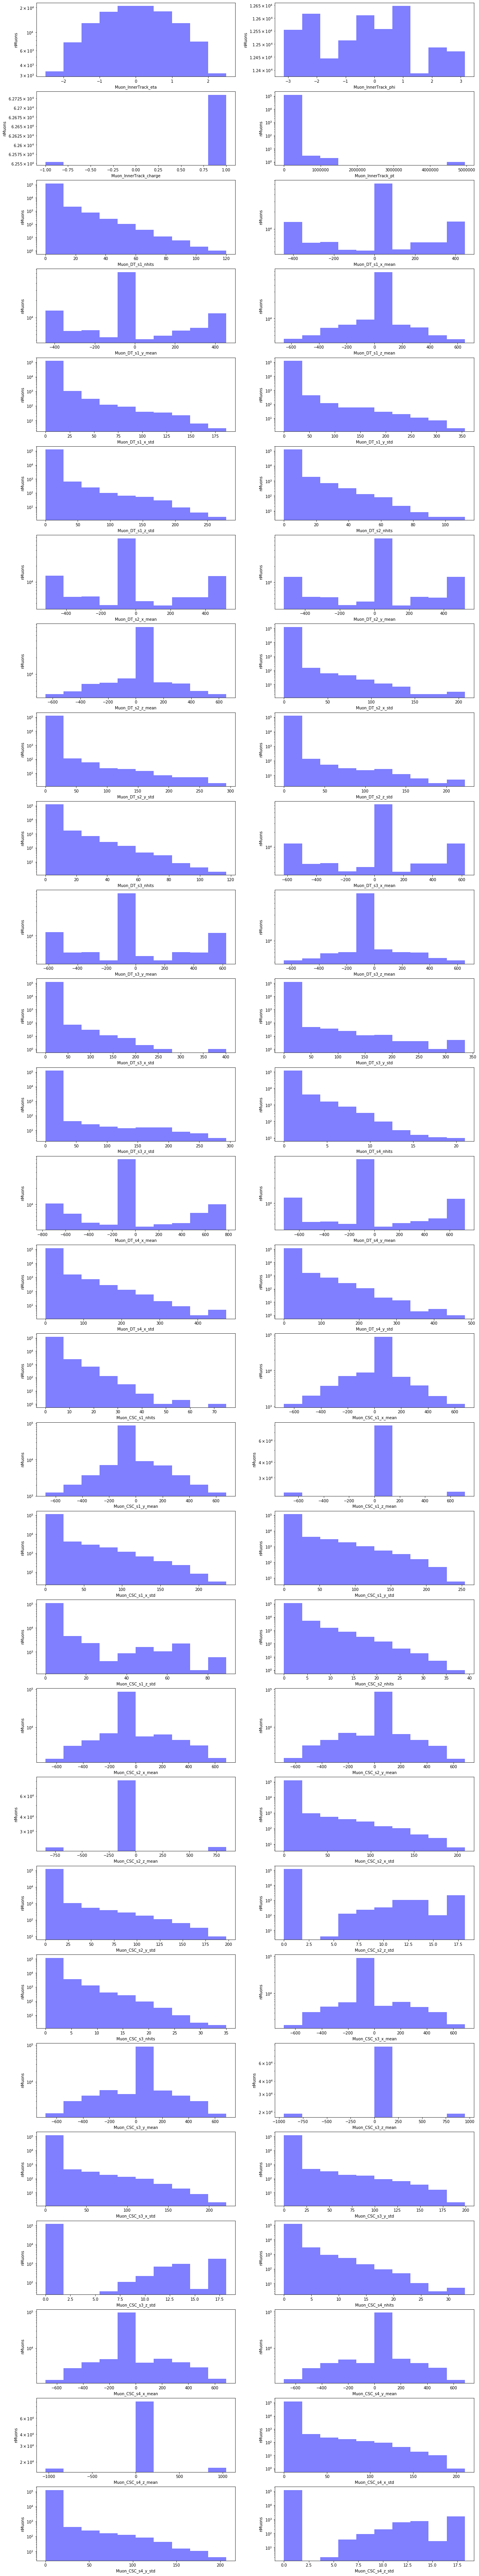

In [134]:
import matplotlib.pyplot as plt

nrows = 29
ncols = 2
counter = 0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 120))

for i in range(nrows):
    for j in range(ncols):

        ax = axes[i][j]

        # Plot when we have data
        if counter < len(data.columns):

            ax.hist(data[data[variablesTrain].columns[counter]], bins=10, color='blue', alpha=0.5, label='{}'.format(data[variablesTrain].columns[counter]))
            ax.set_xlabel(variablesTrain[counter])
            ax.set_ylabel('nMuons')
            ax.set_yscale('log')
#            ax.set_ylim([0, 5])
            #leg = ax.legend(loc='upper left')
            #leg.draw_frame(False)

        # Remove axis when we no longer have data
        else:
            ax.set_axis_off()

        counter += 1

plt.show()

In [135]:
K.clear_session()

model = models.Sequential()

model.add(layers.Dense(512, activation='relu',input_dim=len(variablesTrain))) #, kernel_regularizer=l2(0.001)
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='linear'))
model.summary()

#lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#    initial_learning_rate=1e-2,
#    decay_steps=10000,
#    decay_rate=0.9)

#opt = optimizers.SGD(0.1)
#opt = optimizers.RMSprop(learning_rate=0.1)

#opt = optimizers.Adam(lr=1e-3, decay=1e-3 / 200)
opt = optimizers.Adam(0.00005)
model.compile(loss="mean_squared_error", optimizer=opt)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 512)               30208     
_________________________________________________________________
dense_2 (Dense)              (None, 512)               262656    
_________________________________________________________________
dense_3 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_4 (Dense)              (None, 256)               65792     
_________________________________________________________________
dense_5 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_6 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_7 (Dense)              (None, 64)                8256      
__________

In [136]:
print(np.any(np.isnan(train)))
print(np.any(np.isnan(test)))

False
False


In [137]:
history = model.fit(train[variablesTrain],train[genpT],validation_split=0.1, epochs=1000, batch_size=2000, verbose=1, callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=50,verbose=1)])

Train on 90207 samples, validate on 10024 samples
Epoch 1/1000
90207/90207 [==============================] - 5s 54us/step - loss: 1951385.5968 - val_loss: 1391839.1236
Epoch 2/1000
90207/90207 [==============================] - 5s 50us/step - loss: 1480639.8076 - val_loss: 1079655.6142
Epoch 3/1000
90207/90207 [==============================] - 4s 50us/step - loss: 1251694.0508 - val_loss: 782543.0228
Epoch 4/1000
90207/90207 [==============================] - 5s 50us/step - loss: 749720.4230 - val_loss: 539664.9293
Epoch 5/1000
90207/90207 [==============================] - 5s 50us/step - loss: 372794.1724 - val_loss: 187889.7544
Epoch 6/1000
90207/90207 [==============================] - 4s 50us/step - loss: 161847.7073 - val_loss: 131098.4973
Epoch 7/1000
90207/90207 [==============================] - 5s 50us/step - loss: 113317.5642 - val_loss: 92531.8924
Epoch 8/1000
90207/90207 [==============================] - 5s 50us/step - loss: 90044.5085 - val_loss: 82240.0915
Epoch 9/1000

90207/90207 [==============================] - 4s 50us/step - loss: 49469.7394 - val_loss: 48571.2417
Epoch 72/1000
90207/90207 [==============================] - 4s 49us/step - loss: 52760.7511 - val_loss: 53405.4250
Epoch 73/1000
90207/90207 [==============================] - 4s 50us/step - loss: 50729.7503 - val_loss: 51659.3722
Epoch 74/1000
90207/90207 [==============================] - 5s 51us/step - loss: 49380.5013 - val_loss: 49852.8776
Epoch 75/1000
90207/90207 [==============================] - 4s 50us/step - loss: 48440.8238 - val_loss: 48665.0030
Epoch 76/1000
90207/90207 [==============================] - 4s 49us/step - loss: 62078.7864 - val_loss: 64695.0076
Epoch 77/1000
90207/90207 [==============================] - 5s 51us/step - loss: 61859.9534 - val_loss: 58066.1204
Epoch 78/1000
90207/90207 [==============================] - 4s 49us/step - loss: 56522.6795 - val_loss: 55579.6808
Epoch 79/1000
90207/90207 [==============================] - 4s 50us/step - loss: 5548

90207/90207 [==============================] - 5s 52us/step - loss: 49029.7312 - val_loss: 51114.4815
Epoch 142/1000
90207/90207 [==============================] - 5s 52us/step - loss: 47389.7776 - val_loss: 49898.7413
Epoch 143/1000
90207/90207 [==============================] - 5s 52us/step - loss: 46832.4978 - val_loss: 48439.3619
Epoch 144/1000
90207/90207 [==============================] - 5s 52us/step - loss: 69842.7831 - val_loss: 79874.1118
Epoch 145/1000
90207/90207 [==============================] - 5s 55us/step - loss: 64042.6833 - val_loss: 56961.9624
Epoch 146/1000
90207/90207 [==============================] - 5s 54us/step - loss: 53833.9486 - val_loss: 53392.2623
Epoch 147/1000
90207/90207 [==============================] - 5s 53us/step - loss: 49604.9817 - val_loss: 49807.3480
Epoch 148/1000
90207/90207 [==============================] - 5s 50us/step - loss: 53646.1923 - val_loss: 93017.9538
Epoch 149/1000
90207/90207 [==============================] - 5s 52us/step - lo

90207/90207 [==============================] - 5s 51us/step - loss: 63815.4356 - val_loss: 58518.7379
Epoch 212/1000
90207/90207 [==============================] - 5s 50us/step - loss: 57147.6904 - val_loss: 56549.3936
Epoch 213/1000
90207/90207 [==============================] - 4s 50us/step - loss: 52473.2164 - val_loss: 54962.5211
Epoch 214/1000
90207/90207 [==============================] - 5s 51us/step - loss: 50318.5642 - val_loss: 53374.6031
Epoch 215/1000
90207/90207 [==============================] - 5s 51us/step - loss: 49349.3991 - val_loss: 52244.0480
Epoch 216/1000
90207/90207 [==============================] - 4s 50us/step - loss: 47912.8709 - val_loss: 50473.1623
Epoch 217/1000
90207/90207 [==============================] - 6s 62us/step - loss: 46673.1512 - val_loss: 48644.1747
Epoch 218/1000
90207/90207 [==============================] - 5s 58us/step - loss: 54086.4252 - val_loss: 66205.2830
Epoch 219/1000
90207/90207 [==============================] - 5s 51us/step - lo

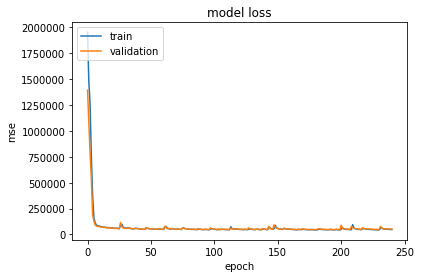

In [138]:
import matplotlib.pyplot as plt

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [139]:
results = model.evaluate(test[variablesTrain], test[genpT], batch_size=128)
print('test loss:', results)


25058/25058 [==============================] - 1s 32us/step
test loss: 55972.415873298945


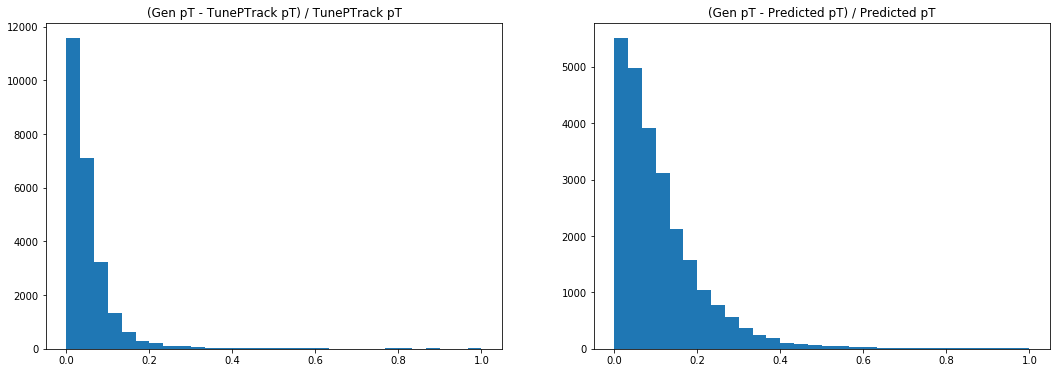

In [140]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))


axes[0].hist(abs(test.Muon_Genpt.values-test.Muon_TunePTrack_pt.values)/test.Muon_TunePTrack_pt.values, bins = 30, range=(0,1)) 
axes[0].set_title("(Gen pT - TunePTrack pT) / TunePTrack pT") 
axes[1].hist(abs(test.Muon_Genpt.values-model.predict(test[variablesTrain]).ravel())/model.predict(test[variablesTrain]).ravel(), bins = 30, range=(0,1)) 
axes[1].set_title("(Gen pT - Predicted pT) / Predicted pT") 
plt.show()

### Selecting Muons with nHits > 6 (50387/125361)

In [141]:
data_gt_6 = data[((data.Muon_DT_s1_nhits + data.Muon_DT_s2_nhits + data.Muon_DT_s3_nhits + data.Muon_DT_s4_nhits + data.Muon_CSC_s1_nhits + data.Muon_CSC_s2_nhits + data.Muon_CSC_s3_nhits + data.Muon_CSC_s4_nhits) > 6)]

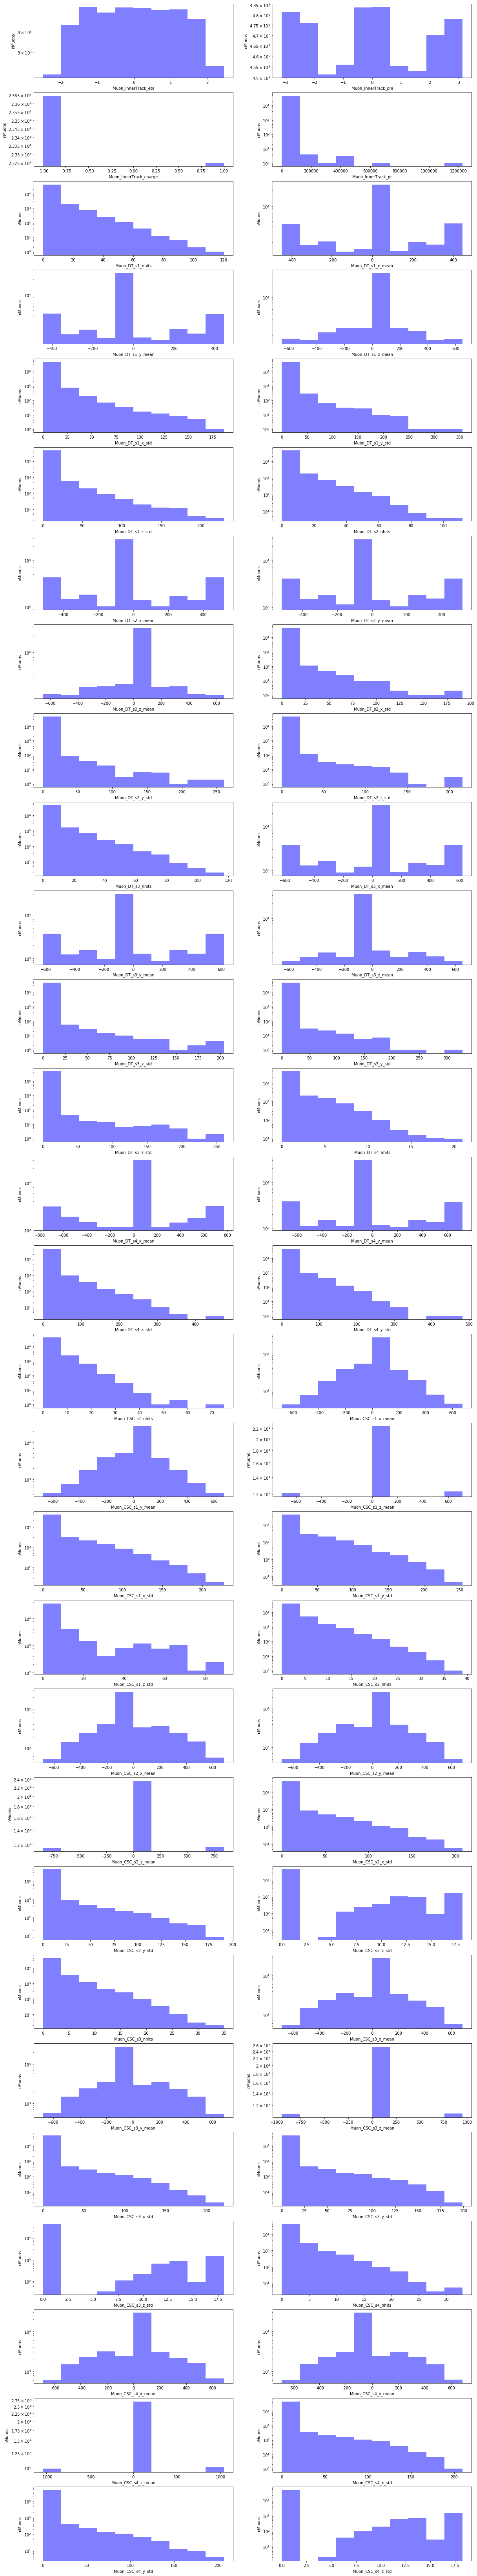

In [142]:
import matplotlib.pyplot as plt

nrows = 29
ncols = 2
counter = 0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 120))

for i in range(nrows):
    for j in range(ncols):

        ax = axes[i][j]

        # Plot when we have data
        if counter < len(data_gt_6.columns):

            ax.hist(data_gt_6[data_gt_6[variablesTrain].columns[counter]], bins=10, color='blue', alpha=0.5, label='{}'.format(data_gt_6[variablesTrain].columns[counter]))
            ax.set_xlabel(variablesTrain[counter])
            ax.set_ylabel('nMuons')
            ax.set_yscale('log')
#            ax.set_ylim([0, 5])
            #leg = ax.legend(loc='upper left')
            #leg.draw_frame(False)

        # Remove axis when we no longer have data
        else:
            ax.set_axis_off()

        counter += 1

plt.show()

In [143]:
train_gt_6, test_gt_6 = train_test_split(data_gt_6, test_size=0.1)

In [144]:
K.clear_session()

model = models.Sequential()

model.add(layers.Dense(512, activation='relu', input_dim=len(variablesTrain)))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='linear'))
model.summary()

opt = optimizers.Adam(0.00005)
model.compile(loss="mean_squared_error", optimizer=opt)

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 512)               30208     
_________________________________________________________________
dense_2 (Dense)              (None, 512)               262656    
_________________________________________________________________
dense_3 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_4 (Dense)              (None, 256)               65792     
_________________________________________________________________
dense_5 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_6 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_7 (Dense)              (None, 64)                8256      
__________

In [145]:
history = model.fit(train_gt_6[variablesTrain],train_gt_6[genpT],validation_split=0.1, epochs=1000, batch_size=2000, verbose=1, callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=50,verbose=1)])

Train on 37982 samples, validate on 4221 samples
Epoch 1/1000
37982/37982 [==============================] - 2s 58us/step - loss: 1773239.3741 - val_loss: 1749373.0718
Epoch 2/1000
37982/37982 [==============================] - 2s 50us/step - loss: 1634060.8033 - val_loss: 2355706.3024
Epoch 3/1000
37982/37982 [==============================] - 2s 50us/step - loss: 1445168.1075 - val_loss: 4582684.1339
Epoch 4/1000
37982/37982 [==============================] - 2s 50us/step - loss: 1337131.6454 - val_loss: 6014514.9230
Epoch 5/1000
37982/37982 [==============================] - 2s 50us/step - loss: 1218914.0581 - val_loss: 5378019.1738
Epoch 6/1000
37982/37982 [==============================] - 2s 51us/step - loss: 1087133.1271 - val_loss: 4646981.2491
Epoch 7/1000
37982/37982 [==============================] - 2s 52us/step - loss: 923295.5189 - val_loss: 3008697.4341
Epoch 8/1000
37982/37982 [==============================] - 2s 53us/step - loss: 795323.0596 - val_loss: 2356086.9218
E

Epoch 71/1000
37982/37982 [==============================] - 2s 62us/step - loss: 57674.7971 - val_loss: 61475.4591
Epoch 72/1000
37982/37982 [==============================] - 2s 56us/step - loss: 57530.1774 - val_loss: 65863.5183
Epoch 73/1000
37982/37982 [==============================] - 2s 57us/step - loss: 56979.8133 - val_loss: 80122.0904
Epoch 74/1000
37982/37982 [==============================] - 2s 54us/step - loss: 56910.4060 - val_loss: 60668.0833
Epoch 75/1000
37982/37982 [==============================] - 2s 54us/step - loss: 56930.9119 - val_loss: 61635.1718
Epoch 76/1000
37982/37982 [==============================] - 2s 53us/step - loss: 56396.1374 - val_loss: 65939.5023
Epoch 77/1000
37982/37982 [==============================] - 2s 52us/step - loss: 56488.6715 - val_loss: 74752.9243
Epoch 78/1000
37982/37982 [==============================] - 2s 52us/step - loss: 65781.7682 - val_loss: 69013.9262
Epoch 79/1000
37982/37982 [==============================] - 2s 51us/ste

37982/37982 [==============================] - 2s 52us/step - loss: 52318.7025 - val_loss: 121847.5584
Epoch 142/1000
37982/37982 [==============================] - 2s 51us/step - loss: 58184.1217 - val_loss: 64697.0420
Epoch 143/1000
37982/37982 [==============================] - 2s 52us/step - loss: 53826.0899 - val_loss: 101993.5650
Epoch 144/1000
37982/37982 [==============================] - 2s 51us/step - loss: 52496.5796 - val_loss: 68700.4644
Epoch 145/1000
37982/37982 [==============================] - 2s 51us/step - loss: 52549.1720 - val_loss: 59757.4219
Epoch 146/1000
37982/37982 [==============================] - 2s 52us/step - loss: 55329.9951 - val_loss: 77721.8431
Epoch 147/1000
37982/37982 [==============================] - 2s 51us/step - loss: 57426.3858 - val_loss: 122988.2856
Epoch 148/1000
37982/37982 [==============================] - 2s 51us/step - loss: 56955.8942 - val_loss: 71666.7938
Epoch 149/1000
37982/37982 [==============================] - 2s 51us/step -

37982/37982 [==============================] - 2s 61us/step - loss: 50489.3147 - val_loss: 66404.0137
Epoch 212/1000
37982/37982 [==============================] - 2s 64us/step - loss: 52324.5475 - val_loss: 71885.7401
Epoch 213/1000
37982/37982 [==============================] - 2s 58us/step - loss: 49271.5017 - val_loss: 73079.2881
Epoch 214/1000
37982/37982 [==============================] - 2s 60us/step - loss: 48435.4130 - val_loss: 68553.8765
Epoch 215/1000
37982/37982 [==============================] - 2s 55us/step - loss: 48400.9404 - val_loss: 68770.4090
Epoch 216/1000
37982/37982 [==============================] - 2s 58us/step - loss: 48304.5184 - val_loss: 60888.3895
Epoch 217/1000
37982/37982 [==============================] - 2s 58us/step - loss: 48343.2803 - val_loss: 75587.6807
Epoch 218/1000
37982/37982 [==============================] - 2s 55us/step - loss: 48248.8352 - val_loss: 59660.6850
Epoch 219/1000
37982/37982 [==============================] - 2s 55us/step - lo

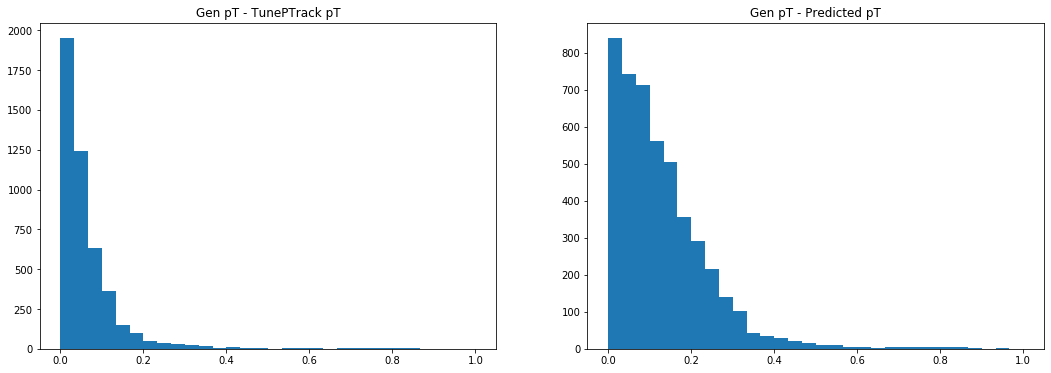

In [146]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))


axes[0].hist(abs(test_gt_6.Muon_Genpt.values-test_gt_6.Muon_TunePTrack_pt.values)/test_gt_6.Muon_TunePTrack_pt.values, bins = 30, range=(0,1)) 
axes[0].set_title("Gen pT - TunePTrack pT") 
axes[1].hist(abs(test_gt_6.Muon_Genpt.values-model.predict(test_gt_6[variablesTrain]).ravel())/model.predict(test_gt_6[variablesTrain]).ravel(), bins = 30, range=(0,1)) 
axes[1].set_title("Gen pT - Predicted pT") 
plt.show()